Rule baseline predictions: 0    177
1    103
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 103, number of negative: 122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1570
[LightGBM] [Info] Number of data points in the train set: 225, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.457778 -> initscore=-0.169292
[LightGBM] [Info] Start training from score -0.169292
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

d:\Data\Documents\GitHub\mc-behavioral-cheat-detection\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


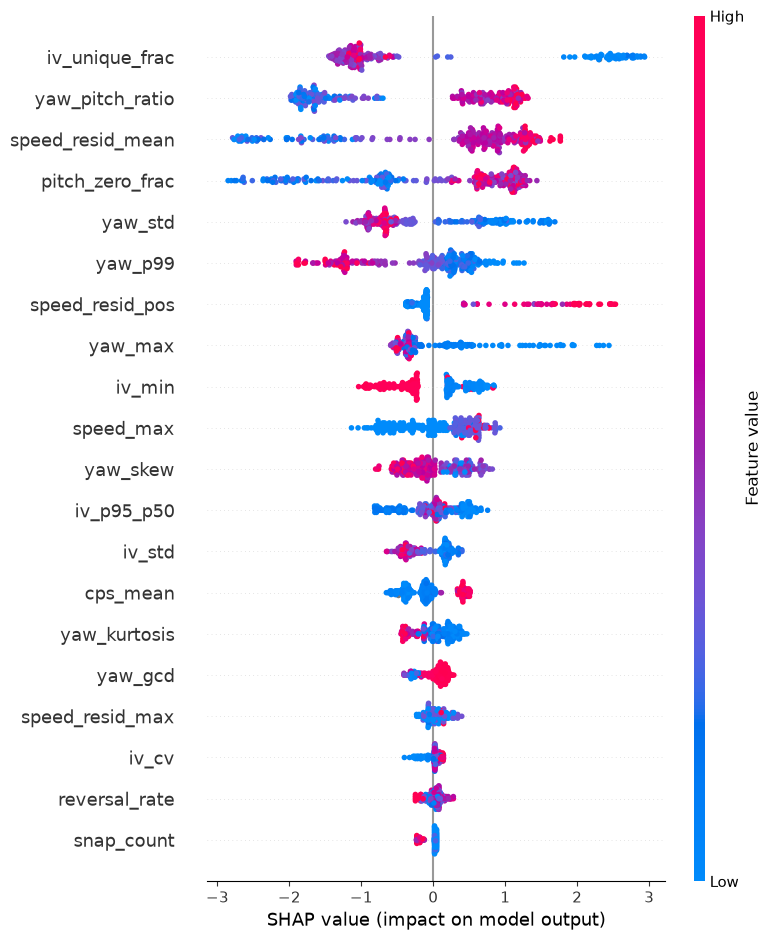

In [1]:
import sys
sys.path.append("../src")

from models import get_feature_cols, rule_baseline, train_cv, novelty_test, plot_calibration
import pandas as pd
import shap

X = pd.read_parquet("../data/processed/features.parquet")
features = get_feature_cols(X)

# Rule baseline first
rule_preds = rule_baseline(X)
print("Rule baseline predictions:", rule_preds.value_counts())

# Supervised model
oof, models = train_cv(X)

# SHAP: explain the first fold's model
explainer = shap.TreeExplainer(models[0])
shap_values = explainer.shap_values(X[features])
shap.summary_plot(shap_values, X[features])

In [2]:
print(sorted(X.columns.tolist()))

['air_const_y_frac', 'airborne_frac', 'cps_mean', 'fall_resid_max', 'fall_resid_std', 'is_cheat', 'iv_cv', 'iv_kurtosis', 'iv_mean_median', 'iv_min', 'iv_p95_p50', 'iv_skew', 'iv_std', 'iv_unique_frac', 'label', 'pitch_zero_frac', 'player', 'reversal_rate', 'session_id', 'snap_count', 'speed_max', 'speed_resid_max', 'speed_resid_mean', 'speed_resid_pos', 'window_id', 'yaw_gcd', 'yaw_kurtosis', 'yaw_max', 'yaw_p99', 'yaw_pitch_ratio', 'yaw_skew', 'yaw_std']


In [3]:
print(X.yaw_gcd.describe())
print(X.iv_cv.describe())

count    280.000000
mean       0.037151
std        0.006250
min        0.020200
25%        0.038687
50%        0.039950
75%        0.040250
max        0.041400
Name: yaw_gcd, dtype: float64
count    279.000000
mean       0.639041
std        0.353225
min        0.128169
25%        0.336744
50%        0.561157
75%        0.888795
max        1.844619
Name: iv_cv, dtype: float64


In [4]:
print(X.groupby("label").yaw_gcd.describe())

             count      mean       std     min       25%       50%     75%  \
label                                                                        
AUTOCLICKER   21.0  0.038838  0.003340  0.0252  0.038700  0.039950  0.0401   
KILLAURA      44.0  0.038665  0.004128  0.0209  0.039600  0.039925  0.0402   
LEGIT        172.0  0.036168  0.007219  0.0202  0.037463  0.039950  0.0403   
REACH         43.0  0.038707  0.003781  0.0218  0.038975  0.039900  0.0402   

                 max  
label                 
AUTOCLICKER  0.04095  
KILLAURA     0.04060  
LEGIT        0.04140  
REACH        0.04050  
